In [1]:
#LangGraph with tools 
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

load_dotenv()

search = TavilySearch(max_results=2)

search.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/groups/302915185514582/posts/740821111723985',
   'title': 'What is the capital of France? - Facebook',
   'content': "PARIS it is the capital and largest city of France. Located on the Seine in the country's north, it is a major cultural and political centre of",
   'score': 0.910998,
   'raw_content': None},
  {'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': 'Paris is the **capital of [France](http://www.parisdigest.com/famous_places_in_france.htm)**, the largest country of [Europe](http://www.parisdigest.com/famous_places_in_europe) with 550 000 km2 (65 millions inhabitants). Founded more than 2000 years ago, Paris is a modern and vibrant city with significant [commercial](http://www.parisdigest.com/menus/shopping.htm), [cultural](http://www.parisdi

In [2]:
def multiply(a, b):
    """Multiply two numbers
    
    Arguments:
        a: int
        b: int

    Returns:
        int: The product of a and b
    """
    return a * b



In [3]:
import langchain_groq

llm = langchain_groq.ChatGroq(model_name="qwen/qwen3-32b")


In [4]:
tools = [search,multiply]

In [5]:
llm_bind_with_tools = llm.bind_tools(tools)

In [6]:
llm_bind_with_tools


_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x12164b290>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x12177f9b0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurat

In [7]:
#State Graph initialization

from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START, END

In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from IPython.display import Image, display

class State(TypedDict):
    messages: Annotated[list, add_messages]

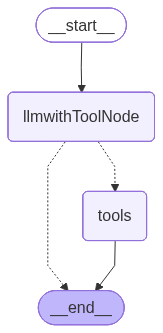

In [9]:
##Graph

#Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_bind_with_tools.invoke(state["messages"][-1].content)]}


builder = StateGraph(State)
builder.add_node("llmwithToolNode",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#Edge definition
builder.add_edge(START,"llmwithToolNode")
builder.add_conditional_edges("llmwithToolNode",
# If the latest message (result) from assistent is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
tools_condition
)
builder.add_edge("tools",END)


#Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [11]:
resp = graph.invoke({"messages":"What is the recent AI news?"})

In [12]:
resp["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/silicon-valleys-new-slogan-lets-get-physical-2026-6", "title": "Silicon Valley\'s New Slogan: Let\'s Get Physical - Business Insider", "score": 0.62824833, "published_date": "Tue, 02 Jun 2026 00:19:41 GMT", "content": "OpenAI is also ramping up its investment in robotics, a sharp reversal from 2020, when the company shuttered the project behind a robotic hand that could solve a Rubik\'s Cube. The team is teaching a robotic arm how to perform household tasks as part of an effort to build a humanoid robot, Business Insider reported earlier this year. OpenAI currently has job openings for several roles in its robotics lab, including machine learning engineers, data acquisition managers, and 3D printing technicians.\\n\\nMeta, too, is bolstering its robotics efforts. Last month, the company acquired humanoid robotics startup Assured Robot Intelligence

In [13]:
import json

raw = resp["messages"][-1].content
data = json.loads(raw)

for r in data["results"]:
    print(r["url"])
    print(r["content"])
    print("---")

https://www.businessinsider.com/silicon-valleys-new-slogan-lets-get-physical-2026-6
OpenAI is also ramping up its investment in robotics, a sharp reversal from 2020, when the company shuttered the project behind a robotic hand that could solve a Rubik's Cube. The team is teaching a robotic arm how to perform household tasks as part of an effort to build a humanoid robot, Business Insider reported earlier this year. OpenAI currently has job openings for several roles in its robotics lab, including machine learning engineers, data acquisition managers, and 3D printing technicians.

Meta, too, is bolstering its robotics efforts. Last month, the company acquired humanoid robotics startup Assured Robot Intelligence for an undisclosed sum. The startup was building AI models for humanoid robots, and its team joined Meta's AI unit, Superintelligence Labs.
---
https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/06/01/ai-tech-brief-exclusive-ai-ad-campaigns-slam-trahan/
Exclusive: 

In [14]:
resp = graph.invoke({"messages":"What is 2*3?"})
resp

{'messages': [HumanMessage(content='What is 2*3?', additional_kwargs={}, response_metadata={}, id='d9b1a9aa-65f5-466c-91e9-5a9496f05e35'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2*3?" So I need to calculate 2 multiplied by 3. Let me check the tools available. There\'s a multiply function that takes two integers, a and b. The parameters are a and b, both required. Since the question is straightforward, I don\'t need to use the search engine tool here. Just call the multiply function with a=2 and b=3. That should give the answer 6. Make sure the JSON is correctly formatted with the function name and arguments.\n', 'tool_calls': [{'id': '1vv1qpwtz', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 1775, 'total_tokens': 1915, 'completion_time': 0.204848467, 'completion_tokens_details': {'reasoning_tokens': 111}, 'pro

In [15]:
for m in resp['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2*3?
================================== Ai Message ==================================
Tool Calls:
  multiply (1vv1qpwtz)
 Call ID: 1vv1qpwtz
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [16]:
resp = graph.invoke({"messages":"Give me latest ai news and then What is 2*3?"})
resp

for m in resp['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me latest ai news and then What is 2*3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qnna5vgnp)
 Call ID: qnna5vgnp
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
  multiply (t0h0ax02s)
 Call ID: t0h0ax02s
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/quickerbettertech/2026/06/07/small-business-tech-news-this-week-from-gusto-zoom-youtube-and-the-fbi/", "title": "Small Business Tech News This Week From Gusto, Zoom, YouTube And The FBI - Forbes", "score": 0.6991933, "published_date": "Sun, 07 Jun 2026 00:00:00 GMT", "content": "President Trump has signed an executive order t

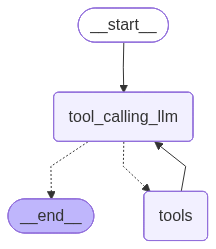

In [22]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_bind_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
config = {"configurable": {"thread_id":"1"}}

resp = graph.invoke({"messages":"Hi, My name is Nupur"},config=config)
resp

{'messages': [HumanMessage(content='Hi, My name is Nupur', additional_kwargs={}, response_metadata={}, id='0a16ecb5-284a-4cc2-9f5b-8666002aea10'),
  AIMessage(content='Hello Nupur! 😊 How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "Hi, My name is Nupur." Let me think about how to respond.\n\nFirst, I need to acknowledge her greeting. A simple "Hello" seems appropriate. Then, I should mention her name to make it personal. Maybe add an emoji to keep it friendly. Also, offer assistance since that\'s the purpose of the chat. Let me check if there\'s any other info needed, but the tools here don\'t require any function calls for a greeting. Just a polite response should suffice.\n'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 1776, 'total_tokens': 1902, 'completion_time': 0.29273979, 'completion_tokens_details': {'reasoning_tokens': 107}, 'prompt_time': 0.12353858, 'prompt_tokens_details': None, 'queue_time': 0.1

In [25]:
resp["messages"][-1].content

'Hello again, Nupur! 😊 How can I assist you today?'

In [27]:
resp = graph.invoke({"messages":"What is my name?"},config=config)
resp["messages"][-1].content

'Your name is Nupur. 😊 How can I assist you today?'

In [28]:
resp = graph.invoke({"messages":"Hey, do you remember my name?"},config=config)
resp["messages"][-1].content

"I remember your name! It's Nupur. 😊 How can I assist you today?"

## Streaming

In [29]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [35]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

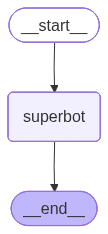

In [36]:
graph = StateGraph(State)

graph.add_node("superbot",superbot)
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile(checkpointer=memory)

##Display

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [38]:
config = {"configurable":{"thread_id":"1"}}

resp = graph_builder.invoke({"messages":"Hi, My name is Nupur and I like listening songs"},config)

In [39]:
resp["messages"][-1].content

'<think>\nOkay, the user introduced herself again as Nupur and mentioned she likes listening to songs. She\'s repeated this message, so maybe she\'s testing if I\'m paying attention or wants to continue the conversation. Let me check the history. The first time, I asked about her favorite genre or artist. Now she\'s sent the same message again.\n\nHmm, perhaps she wants to elaborate more but isn\'t sure how. Or maybe she\'s looking for a different kind of response. Since I already asked about genres and artists, maybe she didn\'t get a chance to answer. I should prompt her again but in a friendly way. Let me make sure to acknowledge her repetition and encourage her to share more details. Also, maybe add a bit more enthusiasm to keep the conversation engaging. Let\'s see. Something like, "Hi again, Nupur! I see you mentioned your love for music again—maybe you have a specific genre or artist you’re into right now? I’d love to know what you\'re vibing to! 🎶" That should work. It\'s frien

## Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [40]:
#Create a thread

config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Nupur and I like listening songs"},config,stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user is Nupur and she likes listening to songs. I should respond in a friendly and welcoming way. Let me start by greeting her and acknowledging her interest in music. Maybe ask her about her favorite genres or artists. I should keep the tone positive and open to encourage further conversation. Also, consider if she might want recommendations or just to share her preferences. Need to make sure the response is concise and not too long. Let me check for any errors and ensure it's in a natural, conversational style.\n</think>\n\nHi Nupur! 🎶 That's such a lovely hobby—music can really lift the mood! Do you have a favorite genre or artist? I'd love to hear what you're into! 🎵✨", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 21, 'total_tokens': 178, 'completion_time': 0.384162627, 'completion_tokens_details': None, 'prompt_time': 0.001102736, 'prompt_tokens_details': None, '

In [41]:
#Create a thread

config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Nupur and I like listening songs"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nupur and I like listening songs', additional_kwargs={}, response_metadata={}, id='27f37ba9-fc1c-47d0-96f3-91d8ada37ea7'), AIMessage(content="<think>\nOkay, the user is Nupur and she likes listening to songs. I should respond in a friendly and welcoming way. Let me start by greeting her and acknowledging her interest in music. Maybe ask her about her favorite genres or artists. I should keep the tone positive and open to encourage further conversation. Also, consider if she might want recommendations or just to share her preferences. Need to make sure the response is concise and not too long. Let me check for any errors and ensure it's in a natural, conversational style.\n</think>\n\nHi Nupur! 🎶 That's such a lovely hobby—music can really lift the mood! Do you have a favorite genre or artist? I'd love to hear what you're into! 🎵✨", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 21, '

In [42]:
#Create a thread

config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Nupur and I like listening songs"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced herself as Nupur and mentioned she likes listening to songs. Let me respond in a friendly and engaging way. I should acknowledge her name and interest.\n\nMaybe ask her what kind of music she enjoys. That way, I can get more details to make the conversation flow. Let me keep the tone cheerful and open-ended. Also, maybe suggest some genres or ask if she has favorite artists. But wait, I shouldn't assume too much. Just a simple question about her music preferences should be enough. Let me make sure the response is concise and inviting.\n</think>\n\nHello Nupur! That's a lovely name. 🎶 Music is such a wonderful thing—it can brighten any day! What kind of songs or genres do you enjoy listening to? I'd love to hear more about your musical tastes! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 174, 'prompt_tokens': 44, 'total_tokens': 218, 'completion_time': 0.41757959, 'compl

In [43]:
#Create a thread

config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"I also like dancing"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nupur and I like listening songs', additional_kwargs={}, response_metadata={}, id='4518bc0d-b42c-4571-8f61-357889c5b645'), HumanMessage(content='Hi, My name is Nupur and I like listening songs', additional_kwargs={}, response_metadata={}, id='1217ed01-7b1d-4a2e-a506-8cd7a92e7d07'), AIMessage(content="<think>\nOkay, the user introduced herself as Nupur and mentioned she likes listening to songs. Let me respond in a friendly and engaging way. I should acknowledge her name and interest.\n\nMaybe ask her what kind of music she enjoys. That way, I can get more details to make the conversation flow. Let me keep the tone cheerful and open-ended. Also, maybe suggest some genres or ask if she has favorite artists. But wait, I shouldn't assume too much. Just a simple question about her music preferences should be enough. Let me make sure the response is concise and inviting.\n</think>\n\nHello Nupur! That's a lovely name. 🎶 Music is such a wonde

## ASTREAM EVENTS

In [44]:
config = {"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream_events({"messages":["Hi, My name is Nupur and I like singing"]},config=config,version="v2"):
    print (event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, My name is Nupur and I like singing']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ea79e-4f9a-7091-8f91-19bb0d476507', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Nupur and I like singing', additional_kwargs={}, response_metadata={}, id='74b4c59f-ff46-4041-84fc-a55a9dc313e4')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019ea79e-4f9d-7260-9c60-5fbacc534546', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:5f77a289-15f5-9214-99c3-52958989abdc'}, 'parent_ids': ['019ea79e-4f9a-7091-8f91-19bb0d476507']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag